In [42]:
import tensorflow
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [43]:
print(X_train.min(), X_train.max())

0 255


In [44]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [46]:
from tensorflow.keras.layers import Flatten,Dense
from tensorflow.keras import Sequential

In [47]:
model=Sequential()

In [50]:
model.add(Flatten(input_shape=(28,28)))

C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [51]:
model.add(Dense(128,activation="relu"))
model.add(Dense(10,activation="softmax"))

In [53]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(loss='sparse_categorical_crossentropy',metrics=["accuracy"],optimizer="adam")

In [58]:
model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9606 - loss: 0.1341 - val_accuracy: 0.9657 - val_loss: 0.1202
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9737 - loss: 0.0893 - val_accuracy: 0.9692 - val_loss: 0.1054
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9794 - loss: 0.0670 - val_accuracy: 0.9682 - val_loss: 0.1055
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9845 - loss: 0.0510 - val_accuracy: 0.9697 - val_loss: 0.0957
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9887 - loss: 0.0387 - val_accuracy: 0.9707 - val_loss: 0.0976
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9909 - loss: 0.0301 - val_accuracy: 0.9752 - val_loss: 0.0891
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9928 - loss: 0.0241 - val_accuracy: 0.9748 - val_loss: 0.0992
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9928 - loss:

In [60]:
y_predprob=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [65]:
y=y_predprob.argmax(axis=1)

In [72]:
y

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [63]:
from sklearn.metrics import accuracy_score

In [66]:
accuracy_score(y_test,y)

0.9769

In [70]:
import matplotlib.pyplot as plt  # not 'matplotlib as plt'

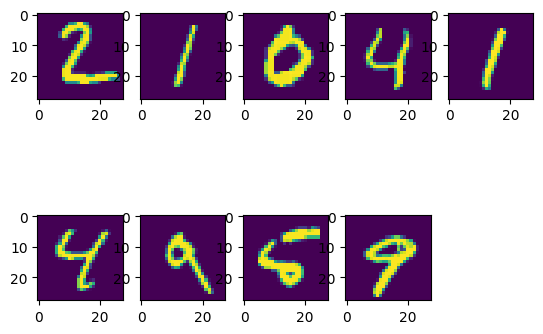

In [80]:
for i in range(1,10):
        plt.subplot(2, 5, i)  # 2 rows, 5 columns grid

        plt.imshow(X_test[i])